In [2]:
# 1. Importação de bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 2. Criando um dataset fictício

dados = {
    "data": pd.date_range("2025-01-01", periods=10, freq="D"),
    "produto": ["A", "B", "C", "A", "B", "C", "A", "B", "C", "A"],
    "quantidade": [10, 5, 8, 12, 7, 9, 15, 6, 11, 13],
    "preco_unitario": [100, 200, 150, 100, 200, 150, 100, 200, 150, 100]
}
df = pd.DataFrame(dados)
df.head()

,data,produto,quantidade,preco_unitario
0,2025-01-01,A,10,100
1,2025-01-02,B,5,200
2,2025-01-03,C,8,150
3,2025-01-04,A,12,100
4,2025-01-05,B,7,200


In [4]:
# 3. Exploração inicial

print(df.shape)       # dimensões
print(df.info())      # tipos de dados
print(df.describe())  # estatísticas

(10, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            10 non-null     datetime64[ns]
 1   produto         10 non-null     object        
 2   quantidade      10 non-null     int64         
 3   preco_unitario  10 non-null     int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 452.0+ bytes
None
                      data  quantidade  preco_unitario
count                   10   10.000000       10.000000
mean   2025-01-05 12:00:00    9.600000      145.000000
min    2025-01-01 00:00:00    5.000000      100.000000
25%    2025-01-03 06:00:00    7.250000      100.000000
50%    2025-01-05 12:00:00    9.500000      150.000000
75%    2025-01-07 18:00:00   11.750000      187.500000
max    2025-01-10 00:00:00   15.000000      200.000000
std                    NaN    3.204164       43.779752


In [5]:
# 4. Criando coluna de receita

df["receita"] = df["quantidade"] * df["preco_unitario"]
df.head()

,data,produto,quantidade,preco_unitario,receita
0,2025-01-01,A,10,100,1000
1,2025-01-02,B,5,200,1000
2,2025-01-03,C,8,150,1200
3,2025-01-04,A,12,100,1200
4,2025-01-05,B,7,200,1400


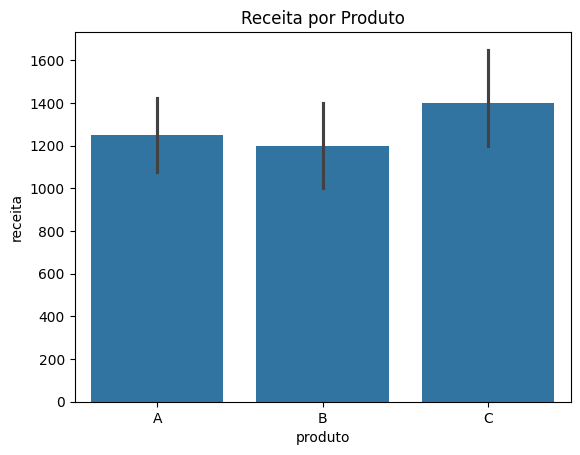

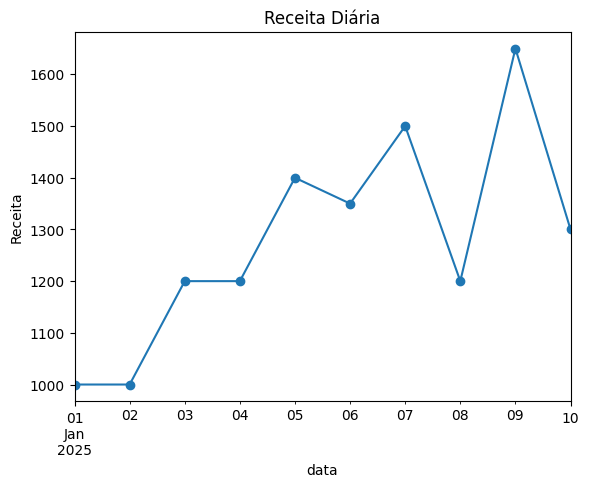

In [6]:
# 5. Visualização simples

# Receita total por produto
sns.barplot(x="produto", y="receita", data=df)
plt.title("Receita por Produto")
plt.show()

# Evolução diária das vendas
df.groupby("data")["receita"].sum().plot(kind="line", marker="o")
plt.title("Receita Diária")
plt.ylabel("Receita")
plt.show()


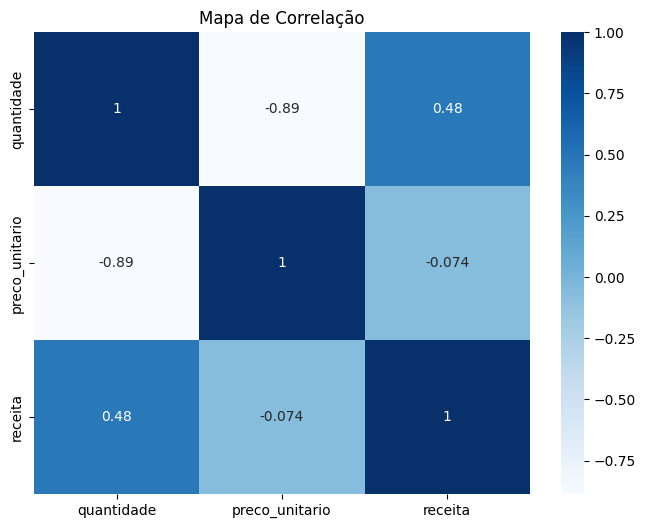

In [7]:
# Seleciona apenas colunas numéricas
corr = df.select_dtypes(include=[np.number]).corr()

# Plotando o heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Mapa de Correlação")
plt.show()

In [ ]:
# 7. Pequena modelagem (previsão simples)

# Importa funções para dividir os dados em treino e teste
from sklearn.model_selection import train_test_split
# Importa o modelo de regressão linear
from sklearn.linear_model import LinearRegression

# Define as variáveis independentes (features) que serão usadas para prever
X = df[["quantidade", "preco_unitario"]]
# Define a variável dependente (target) que queremos prever
y = df["receita"]

# Divide os dados em conjunto de treino (80%) e teste (20%)
# random_state garante que a divisão seja sempre a mesma (reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Cria o modelo de regressão linear
modelo = LinearRegression()
# Treina o modelo com os dados de treino
modelo.fit(X_train, y_train)

# Exibe os coeficientes (peso de cada variável independente)
print("Coeficientes:", modelo.coef_)
# Exibe o intercepto (valor inicial da reta de regressão)
print("Intercepto:", modelo.intercept_)
# Exibe o score (R²), que mede o quão bem o modelo explica os dados de teste
print("Score:", modelo.score(X_test, y_test))


Coeficientes: [95.44117647  6.4       ]
Intercepto: -565.6617647058824
Score: 0.6258157593005877
